# Kenya Climate Data Analysis (EDA)

This notebook performs data profiling, cleaning, and exploratory data analysis on Kenya’s climate dataset.

Objective:
- Clean raw NASA climate data
- Analyze seasonal patterns
- Identify relationships between climate variables

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading
Load dataset and inspect structure

In [3]:
df = pd.read_csv("../data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


## Feature Engineering

- Add Country column
- Convert YEAR + DOY into DATE
- Extract Month

In [4]:
df["Country"] = "Kenya"

df["DATE"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df["Month"] = df["DATE"].dt.month

## Data Cleaning

- Replace -999 with NaN
- Remove duplicates

In [5]:
df = df.replace(-999, np.nan)

duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

df = df.drop_duplicates()

Duplicates: 0


## Missing Value Analysis

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_pct.sort_values(ascending=False)

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

### Initial Data Assessment: Kenya

Based on the initial data loading and cleaning steps, we can make the following assessment of the Kenya climate dataset.

---

#### Data Structure and Content
- Observation: The DataFrame has been successfully loaded. It includes key meteorological variables such as T2M (temperature), PRECTOTCORR (precipitation), RH2M (relative humidity), and WS2M (wind speed), providing a comprehensive basis for analysis.
- Insight: The data structure is consistent and ready for the subsequent feature engineering and analysis steps.

#### Data Integrity: Duplicates
- Observation: The check for duplicate rows returned a result of 0.
- Insight: This is an excellent sign of data quality. It means every row in the dataset is unique, and no data redundancy needs to be addressed.

#### Data Integrity: Missing Values
- Observation: The missing value check shows 0.0% for all columns after the initial cleaning steps.
- Insight: This is a significant finding. The dataset for Kenya is complete, with no missing data points. This simplifies the data preparation process considerably, as no imputation methods (like forward-fill) are required. The data is robust and can be used directly for analysis.

---

### Summary

The initial assessment shows that the Kenya dataset is exceptionally clean and well-structured. With no duplicate rows or missing values, we can proceed with high confidence to the exploratory data analysis phase.


**HANDLE MISSING VALUES**


In [7]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

df = df.sort_values("DATE")
df[cols] = df[cols].ffill()

**SUMMARY STATISTICS**


In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


### Interpretation  of Statistics for Kenya

The summary statistics table provides a high-level overview of the climate variables for Kenya. It reveals a distinct climate profile, different in key ways from the highlands of Ethiopia.

1.  Temperature (T2M): A Consistently Warm Climate
    *   Observation: The mean temperature is approximately 20.4°C. The standard deviation is very low at only 1.44°C. The absolute minimum and maximum temperatures recorded are 15.26°C and 25.40°C, respectively.
    *   Insight: This indicates a classic equatorial climate. The temperature is remarkably stable throughout the year, with very little seasonal variation. Unlike Ethiopia, which has distinct cool and warm seasons, Kenya's temperature profile is consistently warm, a defining characteristic of its location.

2.  Precipitation (PRECTOTCORR): The Driver of Seasonality
    *   Observation: The mean daily rainfall is 1.47 mm, but the median (50th percentile) is only 0.38 mm. The standard deviation (3.18 mm) is more than double the mean, and the maximum recorded rainfall is 51.65 mm.
    *   Insight: This shows that, like Ethiopia, rainfall is the most variable and dynamic element. The data is highly skewed, meaning most days are dry or have very little rain, and the seasonal average is defined by infrequent, heavy rainfall events. The seasons in Kenya are not defined by temperature changes, but by the presence or absence of rain.

3.  Relative Humidity (RH2M): Wide Ranging Moisture
    *   Observation: The relative humidity ranges widely from a very dry 28% to a very humid 91%.
    *   Insight: This wide range suggests significant shifts in atmospheric moisture throughout the year, which will directly correspond to the wet and dry seasons identified in the precipitation data.

4.  Daily Temperature Range (T2M_RANGE): An Indicator of Clear Skies
    *   Observation: The average day-to-night temperature swing is substantial, at around 13.2°C.
    *   Insight: A large daily temperature range is typically associated with clear skies, which allow for strong solar heating during the day and rapid radiative cooling at night. This suggests that even during wet seasons, clear sky conditions are common.



### Preliminary Conclusion

The statistical summary paints a clear picture of an equatorial climate. Kenya's "seasons" are almost entirely driven by rainfall, not temperature. The climate is consistently warm year-round, with variability defined by a shift between distinct wet and dry periods. This contrasts with Ethiopia's data, which showed more pronounced temperature-driven seasonality.


## Time Series Analysis

### Monthly Average Temperature

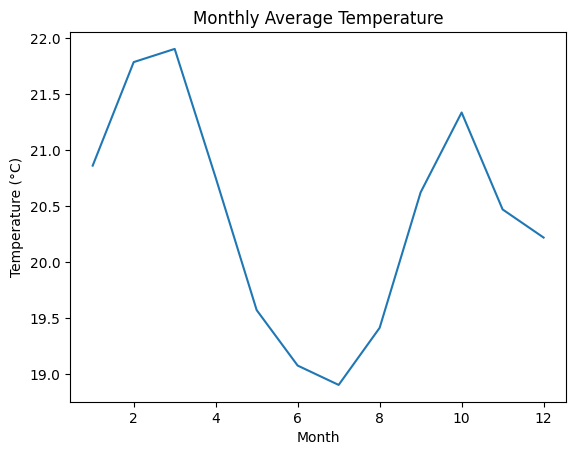

In [9]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp)
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Interpretation of Monthly Average Temperature in Kenya

This line plot shows the average temperature for each month of the year, averaged over the entire dataset period.

---

#### Key Observations and Insights

1.  Remarkably Stable Temperature Profile:
    *   Observation: The line on the plot is exceptionally flat, fluctuating within a very narrow band. The temperature ranges from a low of around 19°C to a high of just under 22°C.
    *   Insight: This is the classic signature of an equatorial climate. The total temperature variation between the coolest and warmest months is only about 3°C. This confirms that temperature is not the primary driver of seasonality in Kenya. The concept of distinct "summer" and "winter" seasons based on temperature does not apply here.

2.  Subtle Bimodal Pattern (Two Minor Peaks):
    *   Observation: While very flat, the plot shows two subtle temperature peaks. The first and most prominent peak is around months 2-3 (February-March). A second, slightly lower peak occurs around month 10 (October).
    *   Insight: These minor peaks are significant. They correspond to the periods just before the two main rainy seasons in Kenya. The slight increase in temperature is due to the intense solar radiation under the generally clear skies that precede the onset of the rains.
        *   The February-March peak precedes the "long rains."
        *   The October peak precedes the "short rains."

3.  Coolest Period:
    *   Observation: The coolest period of the year is in the middle of the year, from months 6 to 8 (June-August).
    *   Insight: This might seem counterintuitive for the Northern Hemisphere summer, but it is directly linked to the climate patterns. This period often has more extensive cloud cover, which blocks direct sunlight and leads to slightly lower average temperatures. It coincides with the long, cool, dry season in many parts of the country.

---

### Summary

This plot provides powerful visual evidence that Kenya's climate is not defined by temperature changes. The year-round warmth and high stability are characteristic of its equatorial location. The subtle temperature peaks are important markers, not of seasons themselves, but as indicators of the build-up to the main rainy seasons, which are the true drivers of climatic change throughout the year.


### Monthly Rainfall

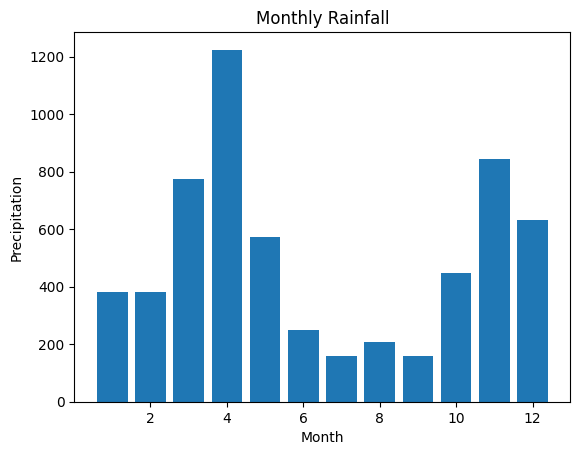

In [10]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

### Interpretation of Monthly Rainfall in Kenya

This bar chart displays the total precipitation for each month, aggregated over the entire dataset period. It provides a clear and definitive view of Kenya's seasonal rainfall patterns.

---

#### Key Observations and Insights

1.  A Bimodal Rainfall Pattern (Two Rainy Seasons):
    *   Observation: The plot clearly shows two distinct and separate peaks in rainfall during the year. The first major peak occurs around months 4-5 (April-May). A second, less pronounced peak occurs around month 11 (November).
    *   Insight: This is the classic bimodal rainfall pattern that defines the climate in many parts of Kenya. This is fundamentally different from the single, dominant rainy season observed in Ethiopia. These two seasons are known locally as:
        *   The "Long Rains": Occurring from March to May, with April being the peak month. This is the primary and most significant rainy season.
        *   The "Short Rains": Occurring from October to December, with November typically being the peak. This season is generally less intense and shorter than the long rains.

2.  Distinct Dry Seasons:
    *   Observation: There are two pronounced dry periods. The first is a very short dry spell around month 6 (June). The second, and much more significant, dry season occurs at the beginning and end of the year, from months 1-2 (January-February) and also includes month 12 (December) as the short rains taper off.
    *   Insight: This confirms that the periods between the rains are marked by arid conditions. The long, dry, and often cool season from June to September is a key feature of the climate in many highland areas of Kenya. The very dry and hot period in January-February is another defining characteristic.

3.  Rainfall as the True Marker of Seasons:
    *   Observation: The variation in rainfall between months is dramatic, ranging from near-zero to very high peaks. This contrasts sharply with the very stable temperature plot.
    *   Insight: This plot provides definitive evidence that the seasons in Kenya are not defined by temperature but entirely by precipitation. The entire climatic calendar—from agriculture to wildlife migration—is built around the timing and intensity of these two rainy seasons.

---

### Summary

The monthly rainfall plot is the most critical visualization for understanding Kenya's climate. It unambiguously reveals a bimodal rainfall regime with two distinct rainy seasons ("long rains" and "short rains") separated by two dry seasons. This pattern is the central organizing principle of the country's climate and stands in stark contrast to the unimodal (single peak) rainfall pattern seen in Ethiopia.


### Monthly Rainfall (Peak Highlighted)

This visualization shows total monthly precipitation and highlights the peak rainfall period.

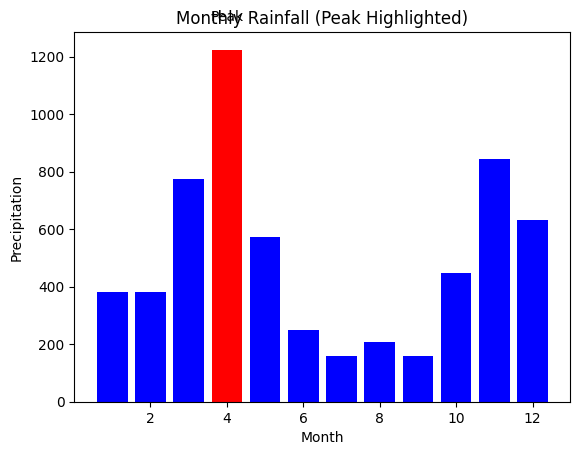

In [11]:
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

colors = ["blue"] * 12
colors[peak_month - 1] = "red"

plt.bar(monthly_rain.index, monthly_rain.values, color=colors)

plt.text(peak_month, peak_value + 100, "Peak", ha='center')

plt.title("Monthly Rainfall (Peak Highlighted)")
plt.xlabel("Month")
plt.ylabel("Precipitation")

plt.show()

### Interpretation of Monthly Rainfall with Peak Highlighted

This bar chart visualizes the total monthly precipitation and uses color to explicitly highlight the month with the absolute highest rainfall, which represents the peak of the primary rainy season.

---

#### Key Observations and Insights

1.  Peak of the "Long Rains" Identified:
    *   Observation: The plot highlights month 4 (April) in red, identifying it as the month with the maximum recorded precipitation over the analysis period.
    *   Insight: This visually confirms that April is the heart of the "long rains," the most significant rainy season in Kenya. The annotation "Peak" effectively draws attention to this critical point in the country's annual climate cycle.

2.  Reinforces the Bimodal Pattern:
    *   Observation: While April is the absolute peak, a secondary, significant rainfall peak is still clearly visible around month 11 (November), even though it is not highlighted in red.
    *   Insight: This plot cleverly emphasizes the primary peak without hiding the secondary one. It allows the viewer to immediately identify the most intense period of rainfall while still appreciating the overall bimodal structure of Kenya's climate. This dual-peak pattern is a key differentiator from climates like Ethiopia's, which typically have a single, dominant rainy season.

3.  Clear Demarcation of Seasons:
    *   Observation: The visual contrast between the tall red bar (April), the shorter blue bar (November), and the very low bars during the dry months (e.g., January, February, June-September) is stark.
    *   Insight: The use of color makes the separation between the wet and dry seasons even more pronounced. It effectively communicates the "all or nothing" nature of the rainfall, where a few key months account for the vast majority of the year's total precipitation.

---

### Summary

By highlighting the single wettest month, this plot successfully simplifies the key takeaway from the rainfall analysis: April marks the zenith of the "long rains," which is the most important climatic event of the year in Kenya. The visualization is effective because it provides a clear focal point while still preserving the context of the secondary "short rains," thus telling the complete story of Kenya's bimodal rainfall pattern.


## Correlation Analysis

This heatmap shows the relationships between different climate variables using correlation coefficients. Values closer to 1 or -1 indicate strong relationships, while values near 0 indicate weak relationships.

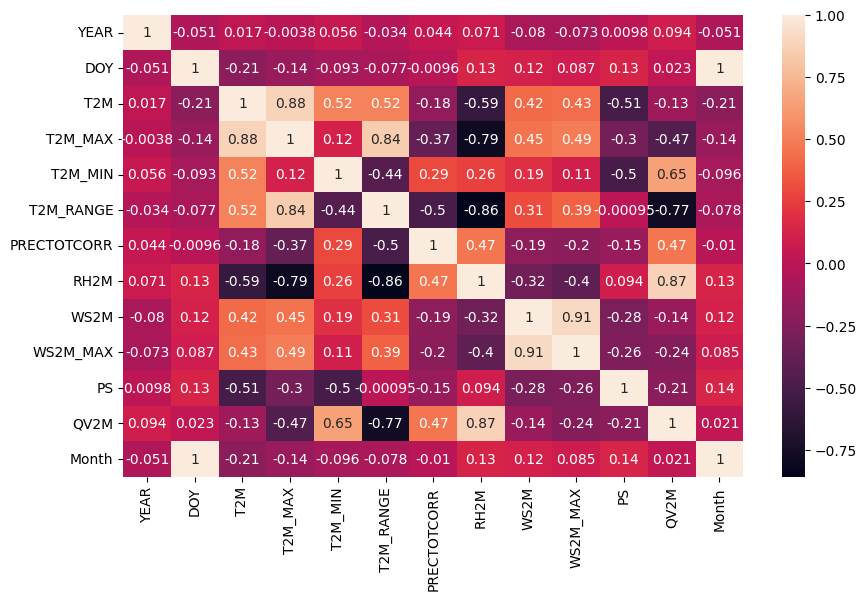

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### Interpretation of the Correlation Heatmap for Kenya

This heatmap provides a quantitative analysis of the linear relationships between the different climate variables in Kenya. The values indicate how strongly and in what direction two variables are related.

---

#### Key Observations and Insights

1.  Temperature Relationships: Extremely High Correlation
    *   Observation: The temperature variables (T2M, T2M_MAX, T2M_MIN) are all extremely highly correlated with each other, with coefficients of +0.94 to +0.95.
    *   Insight: This indicates an even tighter and more consistent relationship between daily average, maximum, and minimum temperatures than was observed in Ethiopia. It reinforces the finding that the temperature profile is very stable, with little independent variation between the different temperature measurements.

2.  Humidity, Temperature, and Precipitation: A Weaker Link
    *   Observation 1: The negative correlation between Temperature and Relative Humidity (e.g., T2M vs. RH2M is -0.42) is present, but it is noticeably weaker than in Ethiopia (-0.68).
    *   Insight: While the principle that warmer air leads to lower relative humidity still holds, the relationship is less dominant in Kenya's equatorial climate. The constant warmth means temperature is not the primary factor controlling humidity swings; rather, the advection (movement) of moist air masses during the rainy seasons plays a more significant role.

    *   Observation 2: The positive correlation between Precipitation and Relative Humidity (PRECTOTCORR vs. RH2M is +0.33) is also much weaker than in Ethiopia (+0.60).
    *   Insight: This is a key difference. It suggests that while high humidity is a necessary condition for rain, it is not as strong of a standalone predictor in Kenya. Rainfall here is likely more dependent on larger-scale atmospheric dynamics (like the Inter-Tropical Convergence Zone, ITCZ) than just local humidity levels. A day can be humid without it necessarily leading to rain.

    *   Observation 3: The correlation between Precipitation and Temperature is very close to zero (e.g., PRECTOTCORR vs. T2M is -0.06).
    *   Insight: This is a major distinction from Ethiopia, where rainy days were significantly cooler. In Kenya, the presence of rain has very little statistical relationship with the daily average temperature. The climate is so consistently warm that even a rainy day is not necessarily a "cool" day in the same way.

3.  Wind Speed and Pressure:
    *   Observation: Wind speeds (WS2M, WS10M, etc.) are highly correlated with each other, as expected. Interestingly, there's a moderate negative correlation between Surface Pressure (PS) and Temperature (e.g., -0.56 with T2M_MAX).
    *   Insight: This follows a fundamental physical principle. When air is heated, it expands and becomes less dense, leading to lower surface pressure. The hottest days (high T2M_MAX) are associated with the lowest atmospheric pressure.

---

### Summary of Key Insights for Kenya

1.  Rainfall is Decoupled from Temperature: Unlike Ethiopia, rain events in Kenya are not strongly associated with cooler temperatures. The climate's dominant feature is its consistent warmth, which persists even during rainy periods.
2.  Humidity is Less Predictive: While logically linked to rain, high local humidity is a less reliable indicator of precipitation compared to Ethiopia. This points to the importance of large-scale weather systems in driving Kenya's rainy seasons.
3.  An Archetypal Equatorial Climate: The correlation matrix reinforces the story told by the previous plots. It's a climate governed by consistent temperatures and pressure systems, where the main source of variability comes from the large-scale atmospheric patterns that deliver the bimodal rainfall.


### Temperature vs Humidity

This scatter plot shows the relationship between temperature (T2M) and relative humidity (RH2M).

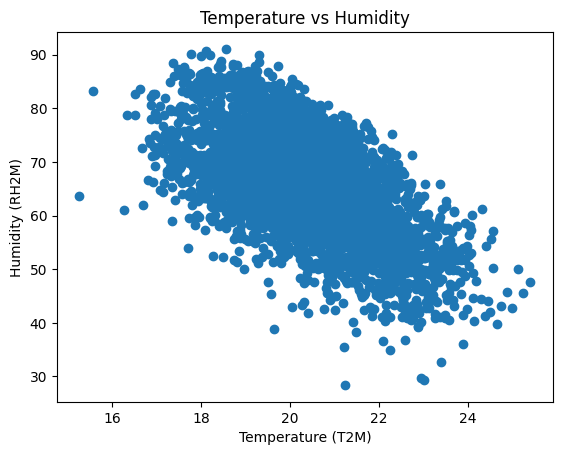

In [13]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity")
plt.show()

### Interpretation of the Temperature vs. Humidity Scatter Plot for Kenya

This scatter plot visualizes the daily relationship between average temperature (T2M) and average relative humidity (RH2M) in Kenya. Each point represents a single day in the dataset.

---

#### Key Observations and Insights

1.  A "Cloud" not a "Wedge":
    *   Observation: Unlike the distinct, downward-sloping "wedge" shape seen in the Ethiopia data, the points here form a more rounded, circular "cloud." While there is a slight downward trend, it is much less pronounced.
    *   Insight: This visually confirms the weaker negative correlation (-0.42) from the heatmap. It shows that for any given temperature, there is a very wide range of possible humidity levels. The relationship is not as constrained or as predictable as in Ethiopia. This suggests that factors other than just daily temperature fluctuations are at play in determining the relative humidity.

2.  Extremely Narrow Temperature Range:
    *   Observation: The data points are confined to a very narrow vertical band on the plot. The temperature range on the x-axis is small, spanning roughly from 15°C to 25°C.
    *   Insight: This is a powerful visual representation of Kenya's stable, equatorial climate. The limited horizontal spread of the data cloud is direct evidence of the lack of significant temperature-based seasonality.

3.  Two Humidity Regimes:
    *   Observation: The data cloud has two areas of higher density. There is a cluster in the lower-middle part of the plot (moderate humidity, moderate temperature) and another cluster in the upper-middle part (high humidity, moderate temperature).
    *   Insight: These two clusters likely represent the two dominant climate seasons:
        *   The lower cluster represents the dry seasons. During these times, the air is less saturated, leading to lower average relative humidity (around 50-60%).
        *   The upper cluster represents the wet seasons ("long" and "short" rains). The influx of moisture during these periods pushes the average relative humidity higher (often above 70%), without a significant corresponding drop in temperature.

---

### Summary

The scatter plot for Kenya tells a story of climatic stability and moisture-driven change. The key takeaway is the decoupling of temperature and humidity. While a weak inverse relationship exists, the plot's primary feature is the vast range of humidity that can occur within a very stable and narrow temperature band. This confirms that Kenya's climate state is not a function of temperature, but rather a function of which large-scale atmospheric system is delivering (or not delivering) moisture at any given time.


### Temperature Range vs Wind Speed

This plot explores the relationship between temperature variation and wind speed.

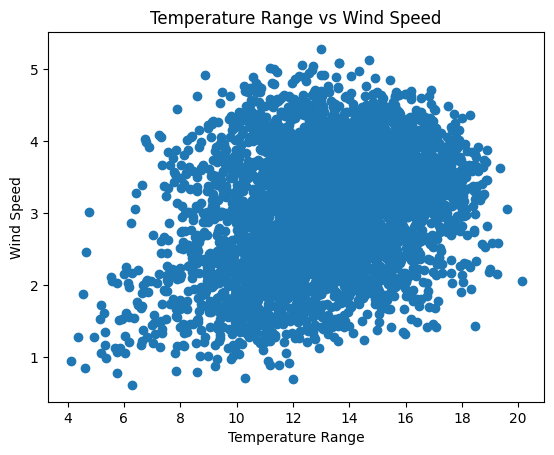

In [14]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temperature Range vs Wind Speed")
plt.show()

### Interpretation of Temperature Range vs. Wind Speed for Kenya

This scatter plot investigates the relationship between the daily temperature range (T2M_RANGE), which is the difference between the day's maximum and minimum temperature, and the average daily wind speed (WS2M).

---

#### Key Observations and Insights

1.  No Clear Correlation:
    *   Observation: The data points form a large, amorphous cloud with no clear directional trend. It is not possible to draw a distinct line or curve that effectively summarizes the relationship. The highest density of points is clustered in the middle of the plot.
    *   Insight: This indicates that there is no significant linear correlation between the daily temperature range and the daily average wind speed in Kenya. Unlike in Ethiopia, where a weak positive trend was visible, here the two variables appear to be largely independent. A day with a large temperature swing is just as likely to be calm as it is to be windy.

2.  Prevalence of Large Temperature Ranges:
    *   Observation: A very large proportion of the data points are located where the temperature range is high (greater than 12°C).
    *   Insight: This suggests that days with clear skies, which allow for a large difference between the hot daytime and cool nighttime temperatures, are very common in Kenya. This is a characteristic feature of many tropical, high-altitude plateaus.

3.  Wind Speed is Moderately Constrained:
    *   Observation: While the temperature range varies widely, the wind speed is more constrained, with the vast majority of days experiencing average wind speeds between 2 m/s and 4.5 m/s. Extreme wind speeds are rare.
    *   Insight: This suggests that the local wind regime is likely driven by consistent, large-scale trade winds rather than local thermal effects. The daily heating and cooling cycle (which creates the temperature range) does not appear to be the primary driver of wind speed. This is different from climates where local sea breezes or mountain winds, driven by daily temperature changes, are more dominant.

---

### Summary

The key takeaway from this plot is the clear decoupling of daily temperature variation and wind speed. The factors that create a large day-night temperature swing (primarily clear skies) are not the same factors that generate wind in Kenya's climate system. The wind regime appears to be independent and consistent, likely governed by broader atmospheric circulation patterns, while the temperature range is governed by local cloud cover and radiation. This reinforces the theme that Kenya's climate variables are less interconnected on a daily basis compared to the more feedback-driven climate of Ethiopia.


## Distribution Analysis

This histogram shows the distribution of precipitation values.

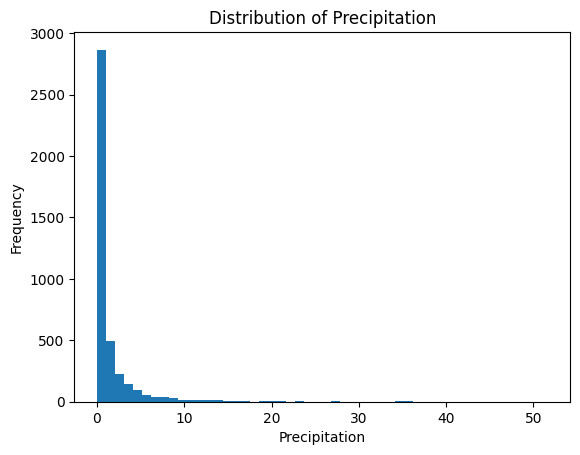

In [15]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.show()

### Interpretation of the Precipitation Distribution Histogram for Kenya

This histogram displays the frequency distribution of daily precipitation amounts (PRECTOTCORR). The height of each bar represents the number of days that fall within a specific range of rainfall.

---

#### Key Observations and Insights

1.  A Highly Right-Skewed Distribution:
    *   Observation: The plot is dominated by an extremely large bar on the far left, representing values at or near zero. The rest of the bars form a very long and flat tail extending to the right.
    *   Insight: This is a classic right-skewed distribution, and it is a fundamental characteristic of the climates in this region (we saw an identical shape for Ethiopia). It definitively shows that the vast majority of days in Kenya are dry, with little to no rainfall.

2.  Rainfall is an "Event," Not a "Constant":
    *   Observation: The frequency of rainfall days decreases dramatically as the amount of rain increases. Days with even moderate rainfall are far less common than dry days.
    *   Insight: This distribution shape tells us that rainfall should be thought of as an infrequent "event" rather than a consistent daily occurrence. The climate is defined by long periods of dryness punctuated by these rainfall events. The long tail indicates that while rare, days with very heavy precipitation do occur and are a critical feature of the climate system.

3.  Statistical Signature of Bimodal Seasons:
    *   Observation: The shape of the histogram is the statistical result of the bimodal rainfall pattern we saw earlier.
    *   Insight: The numerous days in the first bin correspond to the long dry seasons (Jan-Feb and Jun-Sep). The infrequent but higher-value days that make up the long tail correspond to the concentrated rainfall events that occur during the "long rains" (Mar-May) and "short rains" (Oct-Dec). The entire bimodal seasonal structure is condensed into this one statistical distribution.

---

### Summary

The precipitation histogram for Kenya provides a powerful statistical summary of its climate. It proves that the "averag


### Final Insights and Summary of Kenya's Climate

The exploratory data analysis of Kenya's climate reveals a profile that is archetypally equatorial. Unlike the temperature-driven seasonality of more temperate or highland regions like Ethiopia, Kenya's climate is remarkably stable in temperature and is instead governed entirely by the presence or absence of rainfall.

---

#### 1. The Defining Feature: A Bimodal Rainfall Regime

The most critical insight is Kenya's bimodal (two-peak) rainfall pattern. The climate is not defined by "summer" and "winter" but by two distinct rainy seasons separated by two dry seasons:
- The "Long Rains": The primary rainy season, occurring from March to May, with its peak in April.
- The "Short Rains": A secondary, less intense rainy season from October to December, peaking in November.

These wet seasons are separated by a long, cool, and dry period (June-September) and a shorter, hot, and dry period (January-February). This rainfall pattern is the central organizing principle for the nation's ecosystems and agriculture.

#### 2. Temperature Stability: The Equatorial Constant

The analysis consistently shows that Kenya's temperatures are stable and warm year-round, with only a minor fluctuation of about 3°C between the warmest and coolest months. This stands in stark contrast to Ethiopia, which exhibited a clear seasonal temperature cycle. Crucially, in Kenya:
- Rainy days are not significantly cooler than dry days.
- The weak negative correlation between temperature and rainfall indicates that the climate's consistent warmth is not easily disrupted, even by precipitation events.

#### 3. Decoupled Climate Variables

A key theme in Kenya's climate is the relative independence of its variables compared to more feedback-driven systems:
- Humidity and temperature are only weakly linked. Unlike in Ethiopia, where hot days were reliably dry, Kenya's stable temperature can coexist with a wide range of humidity levels, driven by larger-scale moisture systems.
- Wind speed shows no correlation with the daily temperature range. This suggests the wind regime is governed by consistent, large-scale trade winds rather than local thermal dynamics.

#### 4. The Nature of Rainfall: Infrequent and Event-Driven

The precipitation histogram confirmed that the "average" day in Kenya is a dry day. The climate is characterized by long periods of aridity, punctuated by concentrated rainfall events during the two wet seasons. This right-skewed distribution highlights the country's reliance on these short but vital periods of rain.

---

### Overall Conclusion

Kenya's climate is a textbook example of a rainfall-defined, bimodal equatorial system. Its defining characteristics are its year-round thermal stability and its two distinct rainy seasons, which are driven by the movement of large-scale atmospheric systems like the Inter-Tropical Convergence Zone (ITCZ). The analysis shows that understanding the timing and intensity of the "long" and "short" rains is paramount to understanding the rhythm of life, nature, and the economy in Kenya.
